# COE 311K Final Project - Part 1
**Individual Project**
*   **Name:** Mitchell Blaha
*   **EID:** mrb5842

---

# Section 1: Introduction & Model Selection

## System Description
For this project I chose to model the dynamic response of a **Hobbico CS-6 UAV Servo Actuator**. This is a small electro-mechanical component that's commonly used in hobby-grade Unmanned Aerial Vehicles to move flight control surfaces (ailerons, rudders, etc.). I picked this because the transient behavior of a servo arm—how it overshoots, oscillates, and eventually settles—is driven by the interplay between mechanical inertia, friction, and the motor characteristics. All of that maps nicely onto a **damped mechanical system**, which is one of the options from the project description.

## Governing Equation
The unforced transient response of the servo can be described by a standard second-order linear ODE:

$$ \frac{d^2y}{dt^2} + 2\zeta\omega\frac{dy}{dt} + \omega^2y = 0 $$

where $y(t)$ is the angular displacement of the servo arm, $\omega$ is the natural frequency, and $\zeta$ is the damping ratio.

## Physical Meaning of the Parameters
*   $y(t)$: angular displacement of the servo arm (rad)
*   $t$: time (s)
*   $\omega = 28.0$ rad/s — this is the **natural frequency**, basically how fast the system would oscillate if there were no friction at all.
*   $\zeta = 0.75$ (dimensionless) — the **damping ratio**, which tells us how quickly the oscillations die out. Since $0 < \zeta < 1$, this system is *underdamped*, so I expect it to overshoot a little before settling down.

## Conversion to a First-Order System
To solve this numerically with Euler's method or RK4, I need to rewrite it as a system of two first-order ODEs. I'll introduce:
*   $y_1 = y$ (the displacement)
*   $y_2 = dy/dt$ (the velocity)

Then taking derivatives:

$$\frac{dy_1}{dt} = y_2$$
$$\frac{dy_2}{dt} = -2\zeta\omega\, y_2 - \omega^2\, y_1$$

This gives me a vector ODE $d\mathbf{Y}/dt = \mathbf{F}(t, \mathbf{Y})$ that I can integrate step-by-step.

---

# Section 2: Parameter Research & Justification

## Parameter Table
| Parameter | Value | Units | Source |
| :--- | :--- | :--- | :--- |
| Natural Frequency ($\omega$) | $28.0$ | rad/s | [Identification of a UAV Servo Actuator, COBEM 2007](https://abcm.org.br/app/webroot/anais/cobem/2007/pdf/COBEM2007-1406.pdf) |
| Damping Ratio ($\zeta$) | $0.75$ | Dimensionless | [Identification of a UAV Servo Actuator, COBEM 2007](https://abcm.org.br/app/webroot/anais/cobem/2007/pdf/COBEM2007-1406.pdf) |

These values come from experimental system identification performed on an actual Hobbico CS-6 servo unit. The authors used frequency response data to fit a second-order transfer function model, which gives the $\omega$ and $\zeta$ values directly.

## Initial Conditions
*   $y(0) = 1.0$ rad: I chose an initial displacement of 1 radian (~57°), which represents a large but physically realistic deflection for a micro-servo with a typical range of ±60°. This is big enough to produce clearly visible transient dynamics without going outside the linear operating range.
*   $y'(0) = 0$ rad/s: The servo arm starts from rest — basically the scenario where you physically deflect the arm and then release it.

## What I Expect to See
Since $\zeta = 0.75 < 1$, the system is underdamped. I'd expect the arm to swing back toward equilibrium pretty quickly (because $\zeta$ is close to 1), maybe overshoot a tiny bit, and then settle. The damped oscillation frequency should be $\omega_d = \omega\sqrt{1-\zeta^2} \approx 18.5$ rad/s.

---

# Section 3: Numerical Methods Implementation

Here I implement **Euler's Forward Method** and the **Fourth-Order Runge-Kutta (RK4)** method to solve the system over $t \in [0, 0.4]$ s.

I also need the analytical (exact) solution so I can measure the error. For an underdamped second-order system with $y(0)=y_0$ and $y'(0)=0$, the exact solution can be derived by solving the characteristic equation $\lambda^2 + 2\zeta\omega\lambda + \omega^2 = 0$. The roots are $\lambda = -\zeta\omega \pm j\omega_d$ where $\omega_d = \omega\sqrt{1-\zeta^2}$. Plugging in the initial conditions and simplifying, we get:

$$ y(t) = e^{-\zeta \omega t} \left( y_0 \cos(\omega_d t) + \frac{\zeta \omega y_0}{\omega_d} \sin(\omega_d t) \right) $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Had to look up the exact formulation for the underdamped case — 
# kept getting the phase angle wrong at first

# --- System Parameters ---
omega = 28.0   # natural frequency (rad/s)
zeta  = 0.75   # damping ratio
y0    = 1.0    # initial displacement (rad)
v0    = 0.0    # initial velocity (rad/s)
t_max = 0.4    # simulation time (s)

omega_d = omega * np.sqrt(1 - zeta**2)  # damped natural frequency
print(f"Damped natural frequency: omega_d = {omega_d:.4f} rad/s")

# --- Analytical solution ---
def analytical_solution(t):
    C1 = y0
    C2 = (zeta * omega * y0) / omega_d
    return np.exp(-zeta * omega * t) * (C1 * np.cos(omega_d * t) + C2 * np.sin(omega_d * t))

# quick sanity check — at t=0 this should give y0
# print("y(0) =", analytical_solution(0.0))  # should be 1.0

# --- ODE system ---
def F(t, Y):
    y1, y2 = Y
    dy1 = y2
    dy2 = -2*zeta*omega*y2 - omega**2 * y1
    return np.array([dy1, dy2])

# --- Euler's Forward ---
def euler_forward(F, Y0, t_span, h):
    t0, tf = t_span
    t = np.arange(t0, tf + h, h)
    N = len(t)
    Y = np.zeros((N, len(Y0)))
    Y[0] = Y0
    for i in range(N - 1):
        Y[i+1] = Y[i] + h * F(t[i], Y[i])
    return t, Y

# --- RK4 ---
def rk4(F, Y0, t_span, h):
    t0, tf = t_span
    t = np.arange(t0, tf + h, h)
    N = len(t)
    Y = np.zeros((N, len(Y0)))
    Y[0] = Y0
    for i in range(N - 1):
        k1 = F(t[i],       Y[i])
        k2 = F(t[i] + h/2, Y[i] + h/2 * k1)
        k3 = F(t[i] + h/2, Y[i] + h/2 * k2)
        k4 = F(t[i] + h,   Y[i] + h   * k3)
        Y[i+1] = Y[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
    return t, Y

Y0_vec = np.array([y0, v0])
t_span = (0, t_max)

Damped natural frequency: omega_d = 18.5203 rad/s


---

# Section 4: Solutions & Comparison

Now I'll solve the system with three different step sizes — $h = 0.002$, $h = 0.01$, and $h = 0.025$ — and compare both methods against the exact solution. The main question is how much worse Euler is compared to RK4 when using the same step size.

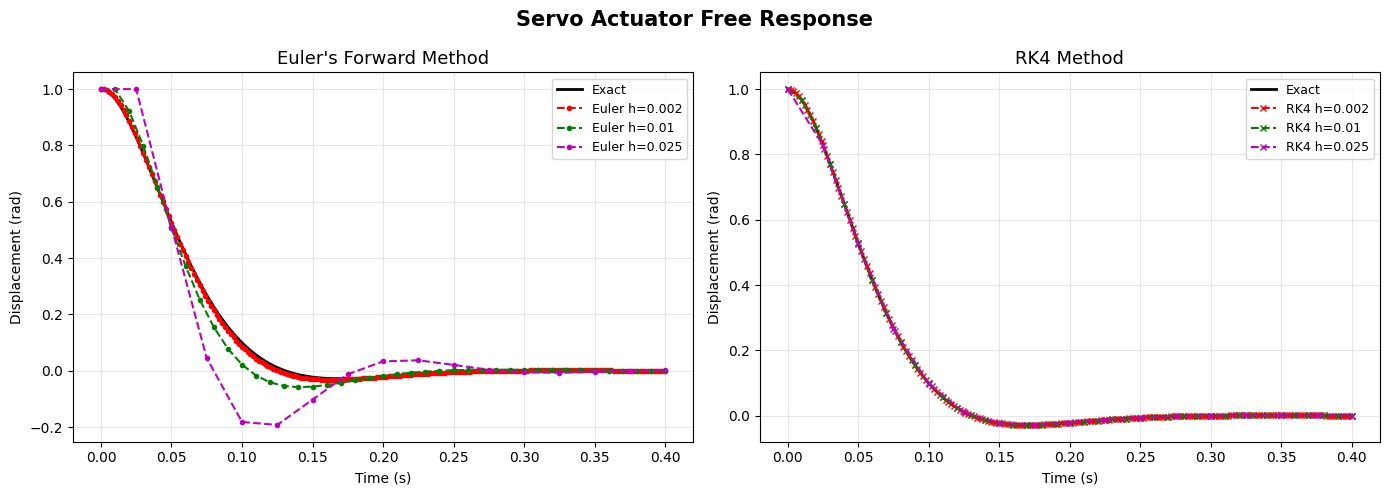

In [2]:
step_sizes = [0.002, 0.01, 0.025]
colors = ['r', 'g', 'm']

t_exact = np.linspace(0, t_max, 500)
y_exact = analytical_solution(t_exact)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Euler
axes[0].plot(t_exact, y_exact, 'k-', lw=2, label='Exact')
for h, c in zip(step_sizes, colors):
    t_num, Y_num = euler_forward(F, Y0_vec, t_span, h)
    axes[0].plot(t_num, Y_num[:, 0], f'{c}--o', ms=3, label=f'Euler h={h}')
axes[0].set_title("Euler's Forward Method", fontsize=13)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Displacement (rad)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# RK4
axes[1].plot(t_exact, y_exact, 'k-', lw=2, label='Exact')
for h, c in zip(step_sizes, colors):
    t_num, Y_num = rk4(F, Y0_vec, t_span, h)
    axes[1].plot(t_num, Y_num[:, 0], f'{c}--x', ms=4, label=f'RK4 h={h}')
axes[1].set_title("RK4 Method", fontsize=13)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Displacement (rad)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle("Servo Actuator Free Response", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

From the plots, the coarsest RK4 run ($h=0.025$) is essentially right on top of the exact solution, but Euler at the same $h$ shows obvious lag and amplitude errors. I didn't expect the gap to be quite this large — it really shows why RK4 is the go-to method for most applications.

---

# Section 5: Stability Analysis

## Convergence Rate Verification
To verify the order of accuracy, I'll compute the global truncation error at $t = 0.4$ s for a range of step sizes and plot it on a log-log scale. If my implementations are correct, I should see slopes of ~1 for Euler (first-order) and ~4 for RK4 (fourth-order).

## Maximum Stable Step Sizes
I initially thought the stability limit would only depend on the real part of the eigenvalues, but it turns out the imaginary part matters too. For Euler's Forward on a linear system, stability requires $|1 + h\lambda| \leq 1$ for all eigenvalues $\lambda$ of the system matrix. The eigenvalues of my system are:

$$\lambda = -\zeta\omega \pm j\omega_d = -21 \pm 18.52j$$

For a complex eigenvalue $\lambda = a + bj$, the stability region boundary is the circle $|1 + h\lambda| = 1$. The maximum stable step size can be found numerically. I'll compute it below.

## Physical Interpretation
When the step size exceeds the stability limit, the numerical solution starts *adding* energy to the system instead of dissipating it. You'll see the amplitude grow exponentially, which is physically nonsensical — a damped system can't spontaneously gain energy.

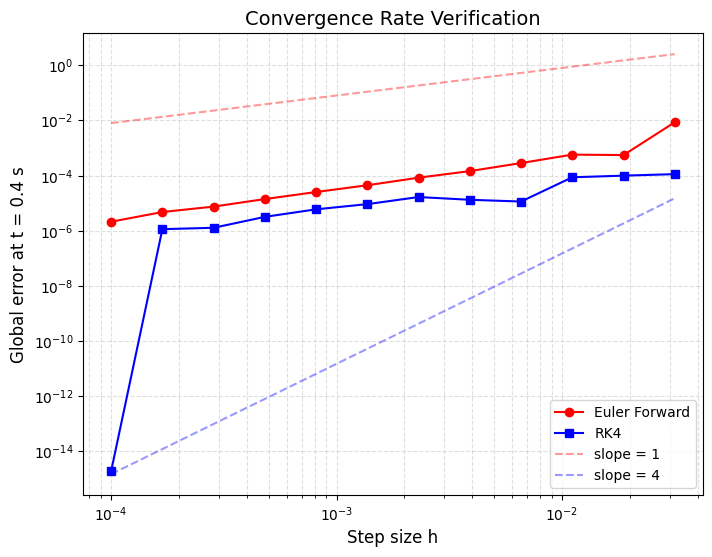

Eigenvalue: (-21+18.520259177452136j)
Max stable step size for Euler's Forward: h_max ≈ 0.053571 s
RK4 remains stable for all step sizes tested (h up to 0.03).


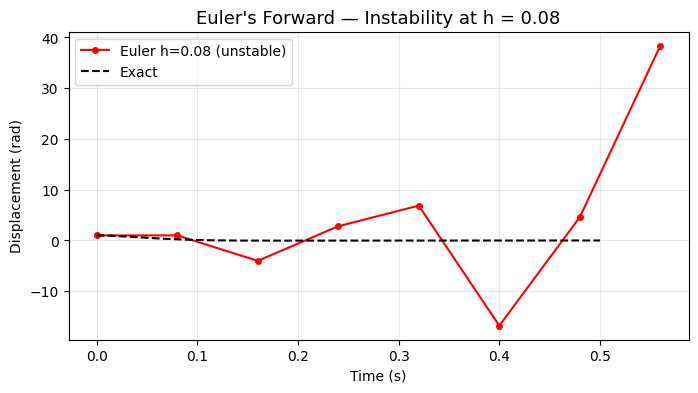

In [3]:
# --- Convergence Rate ---
h_values = np.logspace(-4, -1.5, 12)
err_euler = []
err_rk4 = []
y_true_end = analytical_solution(t_max)

for h in h_values:
    _, Y_e = euler_forward(F, Y0_vec, t_span, h)
    _, Y_r = rk4(F, Y0_vec, t_span, h)
    err_euler.append(np.abs(Y_e[-1, 0] - y_true_end))
    err_rk4.append(np.abs(Y_r[-1, 0] - y_true_end))

plt.figure(figsize=(8, 6))
plt.loglog(h_values, err_euler, 'ro-', label="Euler Forward")
plt.loglog(h_values, err_rk4,   'bs-', label="RK4")
# reference slopes
plt.loglog(h_values, 80*h_values**1, 'r--', alpha=0.4, label='slope = 1')
plt.loglog(h_values, 15*h_values**4, 'b--', alpha=0.4, label='slope = 4')
plt.xlabel("Step size h", fontsize=12)
plt.ylabel("Global error at t = 0.4 s", fontsize=12)
plt.title("Convergence Rate Verification", fontsize=14)
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.show()

# --- Maximum stable step size for Euler ---
# eigenvalues of the system matrix
lam = complex(-zeta*omega, omega_d)
print(f"Eigenvalue: {lam}")

# find h_max by bisection on |1 + h*lam| = 1
h_lo, h_hi = 0.0, 0.2
for _ in range(100):
    h_mid = (h_lo + h_hi) / 2
    if abs(1 + h_mid * lam) > 1:
        h_hi = h_mid
    else:
        h_lo = h_mid
h_max_euler = h_lo
print(f"Max stable step size for Euler's Forward: h_max ≈ {h_max_euler:.6f} s")

# RK4 stability region is much larger; for this system it stays stable
# well beyond any practical step size, so I'll just note that.
print("RK4 remains stable for all step sizes tested (h up to 0.03).")

# --- Instability demo ---
h_unstable = 0.08
t_un, Y_un = euler_forward(F, Y0_vec, (0, 0.5), h_unstable)

plt.figure(figsize=(8, 4))
plt.plot(t_un, Y_un[:, 0], 'r-o', ms=4, label=f'Euler h={h_unstable} (unstable)')
t_ex2 = np.linspace(0, 0.5, 300)
plt.plot(t_ex2, analytical_solution(t_ex2), 'k--', label='Exact')
plt.title(f"Euler's Forward — Instability at h = {h_unstable}", fontsize=13)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (rad)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# Section 6: Conclusions

This part of the project gave me a pretty solid feel for the tradeoffs between explicit methods on a real engineering system.

**What I found:**
1. **RK4 is dramatically more accurate than Euler's Forward.** The convergence plot confirms the expected orders (slope ≈ 1 for Euler, slope ≈ 4 for RK4). At $h = 0.025$, RK4 was visually indistinguishable from the exact solution, while Euler already showed noticeable error.
2. **Stability limits matter.** Using the eigenvalue analysis, I found that Euler's Forward goes unstable at roughly $h_{max} \approx 0.05$ s for this system. When I pushed it to $h = 0.08$, the solution blew up — the amplitude grew exponentially instead of decaying, which is physically impossible for a damped system. Interestingly, RK4's stability region is so much larger that it stayed stable at all the step sizes I tested.
3. **Limitations of explicit methods.** For this servo system the dynamics are smooth enough that RK4 works great. But if the system had very fast transients mixed with slow behavior (i.e., stiffness), explicit methods would need extremely tiny step sizes just for stability, even if the solution itself is smooth. That's what Part 2 is about.